In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import string

In [6]:
# Load the dataset
data = pd.read_csv('political_bias.csv')

In [7]:
# Basic info about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3458 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   3458 non-null   object
 1   Link    3458 non-null   object
 2   Text    3397 non-null   object
 3   Source  3458 non-null   object
 4   Bias    3458 non-null   object
dtypes: object(5)
memory usage: 135.2+ KB


In [8]:
# Checking for missing values
missing_values = data.isnull().sum()
print(missing_values)

Title      0
Link       0
Text      61
Source     0
Bias       0
dtype: int64


In [9]:
# Drop rows with any null (NaN) values
data = data.dropna()

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3397 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   3397 non-null   object
 1   Link    3397 non-null   object
 2   Text    3397 non-null   object
 3   Source  3397 non-null   object
 4   Bias    3397 non-null   object
dtypes: object(5)
memory usage: 159.2+ KB


In [12]:
def fix_encoding_issues(text):
    # Replace common encoding issues with correct characters
    text = text.replace('â€™', '’').replace('â€œ', '“').replace('â€', '”')  # Replace known issues
    return text

# Apply the function to the 'Text' column
data['Text'] = data['Text'].apply(fix_encoding_issues)

# Ensure that the 'Text' column is now treated as a string (forcing the type to string)
data['Text'] = data['Text'].astype('string')

# Verify by checking the data info
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3397 entries, 0 to 3457
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   3397 non-null   object
 1   Link    3397 non-null   object
 2   Text    3397 non-null   string
 3   Source  3397 non-null   object
 4   Bias    3397 non-null   object
dtypes: object(4), string(1)
memory usage: 159.2+ KB


In [13]:
# Show the first few rows of the dataset
data.head()

,Title,Link,Text,Source,Bias
0,John Boltonâ€™s Advice for the â€˜Continuing T...,https://thedispatch.com/article/john-boltons-a...,"With just days until his inauguration, it woul...",TheDispatch,lean right
1,Why Shrubland Makes Southern Californiaâ€™s Wi...,https://thedispatch.com/newsletter/techne/why-...,"Welcome back to Techne! In Star Trek, writers ...",TheDispatch,lean right
2,Los Angelesâ€™ Destruction Was Fueled by Bad P...,https://thedispatch.com/newsletter/capitolism/...,"As fire still rages in the Los Angeles area, I...",TheDispatch,lean right
3,Acquiring Greenland Is a Good Idea. Threatenin...,https://thedispatch.com/article/acquiring-gree...,"Whether it was Will Rogers or Tony Soprano, th...",TheDispatch,lean right
4,Assessing Trumpâ€™s Expansionist Designs,https://thedispatch.com/newsletter/morning/ass...,"Happy Friday! If anyone was wondering, Belgium...",TheDispatch,lean right


In [14]:
# Summary statistics of numerical columns (if any)
data.describe()

,Title,Link,Text,Source,Bias
count,3397,3397,3397,3397,3397
unique,3149,2855,2435,21,5
top,Trumpâ€™s Supposed Unity Message Is a Gloating...,https://www.thenation.com/article/politics/dem...,Error fetching article,Alternet,left
freq,7,7,632,1030,1864


In [15]:
# Checking the distribution of the 'Bias' column
bias_counts = data['Bias'].value_counts()
print(bias_counts)
# over representation of left bias

Bias
left          1864
right          526
lean left      519
center         277
lean right     211
Name: count, dtype: int64


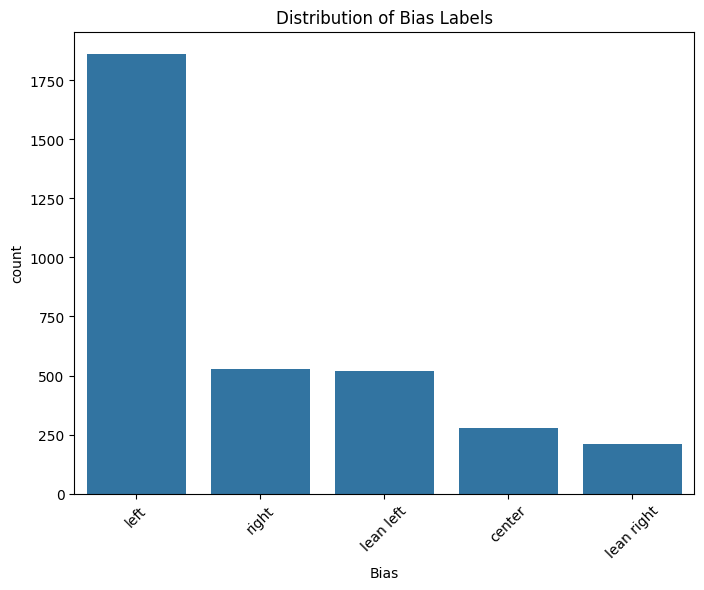

In [16]:
# Visualizing the distribution of Bias labels
plt.figure(figsize=(8,6))
sns.countplot(data=data, x='Bias', order=data['Bias'].value_counts().index)
plt.title('Distribution of Bias Labels')
plt.xticks(rotation=45)
plt.show()

In [17]:
# Text data analysis: wordcloud of the most common words
# Remove punctuation and stopwords
def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    return text

In [18]:
# Apply the clean_text function to the 'Text' column
data['cleaned_text'] = data['Text'].apply(clean_text)

# Most common words (excluding stopwords)
words = ' '.join(data['cleaned_text']).split()
word_counts = Counter(words)
most_common_words = word_counts.most_common(20)

# Display the 20 most common words
common_words_df = pd.DataFrame(most_common_words, columns=['Word', 'Frequency'])
common_words_df

,Word,Frequency
0,the,100234
1,to,53786
2,of,45688
3,and,44357
4,a,38101
5,in,34738
6,that,23709
7,for,17554
8,on,16918
9,is,14234


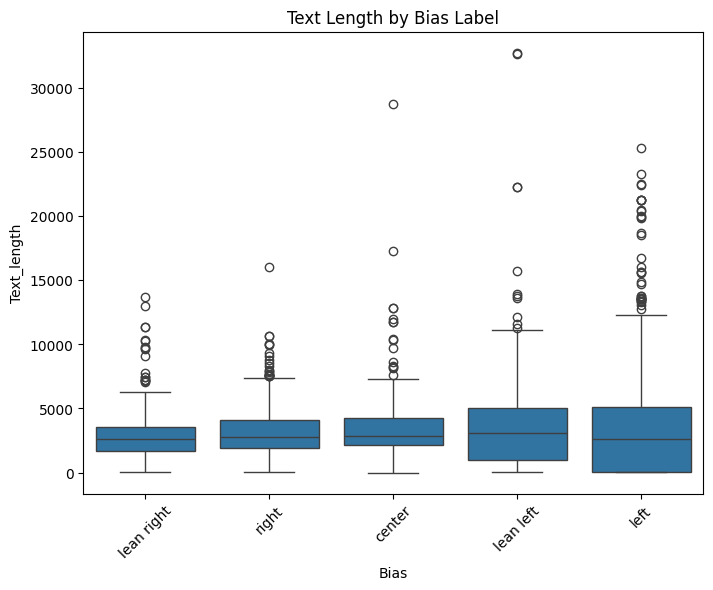

In [19]:
# Investigating length of articles by bias
data['Text_length'] = data['Text'].apply(len)

plt.figure(figsize=(8,6))
sns.boxplot(data=data, x='Bias', y='Text_length')
plt.title('Text Length by Bias Label')
plt.xticks(rotation=45)
plt.show()

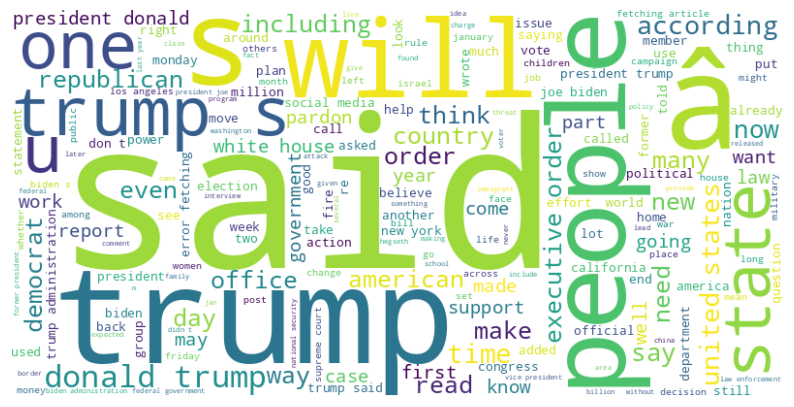

In [20]:
# Generate a wordcloud
text = ' '.join(data['cleaned_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
